In [38]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import polars as pl
import umap
import glob
import umap
import re

In [3]:
# load combined env data
# env_filepath = '../data/envcombined_env_si_airtemp_01.parquet'
env_filepath = '../scripts/python/combined_env_data.parquet'
env_path = os.path.join(env_filepath)
df_env = pd.read_parquet(env_path)

In [5]:
df_env.head()

,Timestamp,Tair_C,Si,Lat,Lon,Alt_m,Campaign,source_file,Tair_K,Pressure_hPa
0,2000-03-09 18:31:10+00:00,9.001,-0.484336,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
1,2000-03-09 18:31:10.250000+00:00,9.012,-0.484815,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
2,2000-03-09 18:31:10.500000+00:00,9.033,-0.485818,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
3,2000-03-09 18:31:10.750000+00:00,9.059,-0.486805,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
4,2000-03-09 18:31:11+00:00,9.078,-0.487472,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN


In [6]:
df_env.columns

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file', 'Tair_K', 'Pressure_hPa'],
      dtype='object')

In [7]:
# Check variables available for each campaign
campaigns = df_env['Campaign'].unique()
summary = {}

for camp in campaigns:
    df_camp = df_env[df_env['Campaign'] == camp]
    valid_counts = df_camp.notna().sum()
    summary[camp] = valid_counts

# Convert to DataFrame for easier viewing
summary_df = pd.DataFrame(summary).T
print(summary_df)

                   Timestamp  Tair_C      Si     Lat     Lon   Alt_m  \
ARM                   429040  429040  429040  429040  429040  429040   
CRYSTAL-FACE-NASA     148610  148610  148610       0       0       0   
CRYSTAL-FACE-UND      185420  182976  132956       0       0       0   
MC3E                  165431  163154  145875  150024  150024  165431   
MIDCIX                 75927   75927   75927       0       0       0   
OLYMPEX               209321  209321  122678  209321  209321  209321   
AIRS-II               312792  312792  312792  312792  312792  312792   
ATTREX                581370  579628  468919  581370  581370  581370   
IPHEX                 287600  286538  192929  285923  285923  285923   
ISDAC                 357071  356773  357071  357071  348190  357061   
POSIDON               190418  186485  182767  133966  133966  133966   
ESCAPE                 67380   67380   67148   67380   67380    3996   
ICE-L                 210561  210525  209137  210530  210530  20

In [55]:
df_env.dtypes

Timestamp    datetime64[ns, UTC]
Tair                     float64
Si                       float64
Campaign                  object
dtype: object

In [9]:
env_campaigns = df_env['Campaign'].unique()
env_campaigns

array(['ARM', 'CRYSTAL-FACE-NASA', 'CRYSTAL-FACE-UND', 'MC3E', 'MIDCIX',
       'OLYMPEX', 'AIRS-II', 'ATTREX', 'IPHEX', 'ISDAC', 'POSIDON',
       'ESCAPE', 'ICE-L', 'MACPEX'], dtype=object)

In [14]:
# TEMP: replace dash with underscore in env df
# TODO: in parsers, change the "-" to "_" for campaign names
df_env["Campaign"] = df_env["Campaign"].str.replace("-", "_")

In [15]:
# check that it was changed correctly
df_env['Campaign'].unique()

array(['ARM', 'CRYSTAL_FACE_NASA', 'CRYSTAL_FACE_UND', 'MC3E', 'MIDCIX',
       'OLYMPEX', 'AIRS_II', 'ATTREX', 'IPHEX', 'ISDAC', 'POSIDON',
       'ESCAPE', 'ICE_L', 'MACPEX'], dtype=object)

In [12]:
# filepath: /home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet
parquet_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"

df = pl.read_parquet(parquet_path)
unique_campaigns = df["campaign"].unique()
print("Unique campaigns:", unique_campaigns.to_list())

Unique campaigns: ['ICE_L', 'CRYSTAL_FACE_UND', 'MPACE', 'ISDAC', 'MACPEX', 'AIRS_II', 'IPHEX', 'ARM', 'CRYSTAL_FACE_NASA', 'MC3E', 'MIDCIX', 'ATTREX']


In [18]:
# load cpi3m embeddings (from SSL Model v3)
cpi3m_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"
scan = pl.scan_parquet(cpi3m_path)

# campaigns = [
#     "CRYSTAL_FACE_NASA",
#     "ARM",
#     "CRYSTAL_FACE_UND",
#     "MIDCIX",
#     "MC3E",
#     "ATTREX"
# ]
campaigns = df_env['Campaign'].unique()

cpi3m_selected = (
    scan
    .filter(pl.col("campaign").is_in(campaigns))
    .collect()
)

print(type(cpi3m_selected))
print(cpi3m_selected.head())


<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 5)
┌─────────────────────┬─────────────────────┬──────────┬─────────────────────┬─────────────────────┐
│ campaign_file_id    ┆ cls_features        ┆ campaign ┆ filename            ┆ head_features       │
│ ---                 ┆ ---                 ┆ ---      ┆ ---                 ┆ ---                 │
│ str                 ┆ list[f32]           ┆ str      ┆ str                 ┆ list[f32]           │
╞═════════════════════╪═════════════════════╪══════════╪═════════════════════╪═════════════════════╡
│ AIRS_II/1114-115708 ┆ [-1.573681,         ┆ AIRS_II  ┆ 1114-115708_753_18. ┆ [-0.174372,         │
│ _753_18.png         ┆ -1.34678, … 1.0547… ┆          ┆ png                 ┆ 0.220068, … 0.1956… │
│ AIRS_II/1114-115708 ┆ [-0.664088,         ┆ AIRS_II  ┆ 1114-115708_753_25. ┆ [0.150885,          │
│ _753_25.png         ┆ -0.620979, … 1.610… ┆          ┆ png                 ┆ 0.086997, …         │
│                     ┆           

In [25]:
# number of samples per campaign
counts = (
    cpi3m_selected
    .with_columns(pl.col("campaign").str.replace_all("-", "_"))
    .group_by("campaign")
    .len()
    .sort("campaign")
)

print(counts)
print(counts.shape)

shape: (11, 2)
┌───────────────────┬─────────┐
│ campaign          ┆ len     │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ AIRS_II           ┆ 92201   │
│ ARM               ┆ 295703  │
│ ATTREX            ┆ 129128  │
│ CRYSTAL_FACE_NASA ┆ 78152   │
│ CRYSTAL_FACE_UND  ┆ 1617826 │
│ …                 ┆ …       │
│ IPHEX             ┆ 40692   │
│ ISDAC             ┆ 505812  │
│ MACPEX            ┆ 80240   │
│ MC3E              ┆ 187558  │
│ MIDCIX            ┆ 90761   │
└───────────────────┴─────────┘
(11, 2)


In [11]:
# Print the date range of campaign
campaign = 'ATTREX'
df = cpi3m_selected.filter(cpi3m_selected['campaign']==campaign)

# Extract datetime from the filename
df = df.with_columns(
    pl.col("filename")
    .str.extract(r"(\d{4}_\d{4}_\d{6})")  # Extract the datetime part
    .str.strptime(pl.Datetime, format="%Y_%m%d_%H%M%S")  # Corrected: use 'format' instead of 'fmt'
    .alias("datetime")  # Add as a new column
)

# Calculate the date range
start_date = df["datetime"].min()
end_date = df["datetime"].max()

print(f"Date range: {start_date} to {end_date}")

Date range: 2014-03-04 17:41:32 to 2014-03-05 06:09:23


In [ ]:
# Lazy scan
lf = pl.scan_parquet(cpi3m_path)

# Get unique campaign values
campaigns = (
    lf.select("campaign")
      .unique()
      .collect()
)

print(campaigns['campaign'].to_list())

In [ ]:
lf = pl.scan_parquet(cpi3m_path)

result = (
    lf.select(["campaign", "filename"])
      .group_by("campaign")
      .agg(
          pl.col("filename").head(5).alias("filenames")
      )
      .collect()
)

for row in result.iter_rows(named=True):
    print(f"\nCampaign: {row['campaign']}")
    for f in row["filenames"]:
        print(f"  {f}")

In [27]:
# sample random subset of each campaign
n_per_campaign = 20_000

cpi3m_sampled = (
    cpi3m_selected
    .group_by("campaign")
    .agg(
        pl.all().sample(n=n_per_campaign, with_replacement=False)
    )
    .explode(pl.all().exclude("campaign"))
)

print(cpi3m_sampled.shape)

(220000, 5)


In [28]:
# UMAP to reduce embeddings to 3-D 
X = cpi3m_sampled['cls_features'].to_list()
X = np.array(X, dtype=np.float32)
print("Embedding matrix:", X.shape)
# Run UMAP → 3 dimensions
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=100,
    min_dist=0.1,
    metric="cosine",
    n_jobs=-1
    # random_state=42,
)

X_umap = umap_model.fit_transform(X)
print("UMAP shape:", X_umap.shape)

Embedding matrix: (220000, 384)
UMAP shape: (220000, 3)


In [29]:
# Save UMAP embeddings
save_dir = '../data/umap'
save_filename = 'umap_d3_n220k_11campaigns.csv'
save_filepath = os.path.join(save_dir, save_filename)
np.savetxt(
    save_filepath,
    X_umap,
    delimiter=","
)

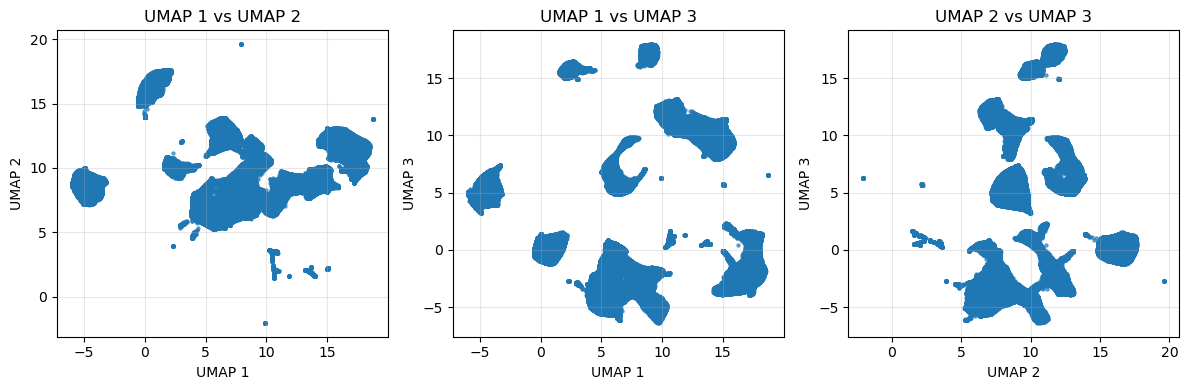

In [30]:
# plot UMAP in 3D
# Convert to named columns for clarity
umap1 = X_umap[:, 0]
umap2 = X_umap[:, 1]
umap3 = X_umap[:, 2]

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# ---- Plot 1: UMAP1 vs UMAP2 ----
plt.subplot(1, 3, 1)
plt.scatter(umap1, umap2, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 1 vs UMAP 2")
plt.grid(alpha=0.3)

# ---- Plot 2: UMAP1 vs UMAP3 ----
plt.subplot(1, 3, 2)
plt.scatter(umap1, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP 1 vs UMAP 3")
plt.grid(alpha=0.3)

# ---- Plot 3: UMAP2 vs UMAP3 ----
plt.subplot(1, 3, 3)
plt.scatter(umap2, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP 2 vs UMAP 3")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# normalize UMAP embeddings to RGB
# Assume X_umap is (N, 3)
umap_norm = (X_umap - X_umap.min(axis=0)) / (X_umap.max(axis=0) - X_umap.min(axis=0))
umap_norm = np.clip(umap_norm, 0, 1)       # safety

# Convert to 0–255 uint8 RGB
rgb = (umap_norm * 255).astype(np.uint8)

print(rgb.shape)   # (N, 3)

(220000, 3)


In [34]:
# Check CPI image filename formatting 
for campaign in cpi3m_sampled.select("campaign").unique().to_series():
    print(f"Campaign: {campaign}")
    samples = (
        cpi3m_sampled
        .filter(pl.col("campaign") == campaign)
        .select("filename")
        .head(5)
        .to_series()
        .to_list()
    )
    for fname in samples:
        print(f"  {fname}")
    print()

Campaign: ATTREX
  2014_0305_013120_74.png
  2014_0304_180615_74.png
  2014_0305_051618_45.png
  2014_0305_055219_34.png
  2014_0304_233205_146.png

Campaign: ICE_L
  2007_1116_180054_703_105.png
  2007_1116_215510_765_93.png
  2007_1116_213111_696_3.png
  2007_1211_202224_912_7.png
  2007_1116_191056_330_15.png

Campaign: MIDCIX
  2004_0506_162213_462_57.png
  2004_0506_165843_456_49.png
  2004_0506_174422_96_13.png
  2004_0502_181436_515_35.png
  2004_0502_171635_663_45.png

Campaign: IPHEX
  2014_0510_171816_691_76.png
  2014_0509_200606_204_7.png
  2014_0518_121328_800_14.png
  2014_0611_193325_481_32.png
  2014_0608_202330_98_88.png

Campaign: CRYSTAL_FACE_NASA
  2002_0716_212019_215_7.png
  2002_0728_213513_690_71.png
  2002_0716_205500_461_17.png
  2002_0729_151559_597_164.png
  2002_0719_214803_539_114.png

Campaign: CRYSTAL_FACE_UND
  2002_0726_222023_199_88.png
  2002_0728_200630_662_66.png
  2002_0716_204900_704_32.png
  2002_0726_224741_141_9.png
  2002_0716_221756_464_75.p

In [39]:
# Correct issues with filename formatting for AIRS-II campaign 
# the year is missing in front for some filenames 
def fix_airsii_filename(filename):
    if re.match(r"^\d{4}_", filename):
        return filename
    m = re.match(r"(\d{4})-(\d{6})", filename)
    if m:
        flight, yymmdd = m.groups()
        return f"2003_{yymmdd}_{flight}" + filename[m.end():]
    return filename

cpi3m_sampled = cpi3m_sampled.with_columns(
    pl.when(pl.col("campaign") == "AIRS_II")
      .then(pl.col("filename").map_elements(fix_airsii_filename, return_dtype=pl.String))
      .otherwise(pl.col("filename"))
      .alias("filename_fixed")
)

In [40]:
# Now use "filename_fixed" for your timestamp parsing
cpi3m_sampled = cpi3m_sampled.with_columns(
    pl.col("filename_fixed")
      .str.split("_")
      .list.slice(0, 3)
      .list.join("_")
      .str.strptime(pl.Datetime, format="%Y_%m%d_%H%M%S", strict=False)
      .alias("timestamp")
)

print(cpi3m_sampled.select(["filename", "timestamp"]).head())

shape: (5, 2)
┌──────────────────────────┬─────────────────────┐
│ filename                 ┆ timestamp           │
│ ---                      ┆ ---                 │
│ str                      ┆ datetime[μs]        │
╞══════════════════════════╪═════════════════════╡
│ 2011_0407_162226_88.png  ┆ 2011-04-07 16:22:26 │
│ 2011_0411_174548_43.png  ┆ 2011-04-11 17:45:48 │
│ 2011_0416_202524_120.png ┆ 2011-04-16 20:25:24 │
│ 2011_0411_173835_1.png   ┆ 2011-04-11 17:38:35 │
│ 2011_0421_193526_10.png  ┆ 2011-04-21 19:35:26 │
└──────────────────────────┴─────────────────────┘


In [41]:
cpi3m_sampled = cpi3m_sampled.with_columns([
    pl.Series("r", rgb[:, 0]),
    pl.Series("g", rgb[:, 1]),
    pl.Series("b", rgb[:, 2]),
])

print(cpi3m_sampled.select(["r", "g", "b"]).head())

shape: (5, 3)
┌─────┬─────┬─────┐
│ r   ┆ g   ┆ b   │
│ --- ┆ --- ┆ --- │
│ u8  ┆ u8  ┆ u8  │
╞═════╪═════╪═════╡
│ 62  ┆ 206 ┆ 61  │
│ 60  ┆ 206 ┆ 58  │
│ 62  ┆ 216 ┆ 65  │
│ 78  ┆ 225 ┆ 76  │
│ 80  ┆ 230 ┆ 76  │
└─────┴─────┴─────┘


In [42]:
cpi3m_sampled.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8
"""MACPEX""","""MACPEX/2011_0418_192022_93.png""","[-0.379777, -0.954685, … 0.648449]","""2011_0407_162226_88.png""","[0.148294, 0.070793, … 0.099497]","""2011_0407_162226_88.png""",2011-04-07 16:22:26,62,206,61
"""MACPEX""","""MACPEX/2011_0407_165932_13.png""","[0.000992, -2.405416, … -0.646428]","""2011_0411_174548_43.png""","[-0.026434, -0.11272, … 0.145598]","""2011_0411_174548_43.png""",2011-04-11 17:45:48,60,206,58
"""MACPEX""","""MACPEX/2011_0407_155837_71.png""","[-0.252868, -0.203787, … 2.238543]","""2011_0416_202524_120.png""","[-0.066077, -0.02347, … -0.032405]","""2011_0416_202524_120.png""",2011-04-16 20:25:24,62,216,65
"""MACPEX""","""MACPEX/2011_0411_181758_65.png""","[0.491084, -2.506011, … 4.387925]","""2011_0411_173835_1.png""","[0.044021, 0.005669, … -0.025395]","""2011_0411_173835_1.png""",2011-04-11 17:38:35,78,225,76
"""MACPEX""","""MACPEX/2011_0403_194820_69.png""","[-0.371169, -3.149739, … 4.488536]","""2011_0421_193526_10.png""","[0.127149, 0.06606, … -0.02375]","""2011_0421_193526_10.png""",2011-04-21 19:35:26,80,230,76


In [43]:
cpi3m_sampled.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [45]:
cpi3m_sampled.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [47]:
# rename column name and campaigns to match env df
# cpi3m_sampled = (
#     cpi3m_sampled
#     # # rename column
#     # .rename({"campaign": "Campaign"})
#     # replace values
#     .with_columns(
#         pl.col("campaign")
#         .replace({
#             "CRYSTAL_FACE_UND": "CRYSTAL-FACE-UND",
#             "CRYSTAL_FACE_NASA": "CRYSTAL-FACE-NASA",
#         })
#     )
# )
df_cpi = cpi3m_sampled
df_cpi['campaign'].unique()

campaign
str
"""ISDAC"""
"""CRYSTAL_FACE_NASA"""
"""IPHEX"""
"""MACPEX"""
"""ARM"""
…
"""ICE_L"""
"""ATTREX"""
"""AIRS_II"""


In [48]:
df_cpi.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8
"""MACPEX""","""MACPEX/2011_0418_192022_93.png""","[-0.379777, -0.954685, … 0.648449]","""2011_0407_162226_88.png""","[0.148294, 0.070793, … 0.099497]","""2011_0407_162226_88.png""",2011-04-07 16:22:26,62,206,61
"""MACPEX""","""MACPEX/2011_0407_165932_13.png""","[0.000992, -2.405416, … -0.646428]","""2011_0411_174548_43.png""","[-0.026434, -0.11272, … 0.145598]","""2011_0411_174548_43.png""",2011-04-11 17:45:48,60,206,58
"""MACPEX""","""MACPEX/2011_0407_155837_71.png""","[-0.252868, -0.203787, … 2.238543]","""2011_0416_202524_120.png""","[-0.066077, -0.02347, … -0.032405]","""2011_0416_202524_120.png""",2011-04-16 20:25:24,62,216,65
"""MACPEX""","""MACPEX/2011_0411_181758_65.png""","[0.491084, -2.506011, … 4.387925]","""2011_0411_173835_1.png""","[0.044021, 0.005669, … -0.025395]","""2011_0411_173835_1.png""",2011-04-11 17:38:35,78,225,76
"""MACPEX""","""MACPEX/2011_0403_194820_69.png""","[-0.371169, -3.149739, … 4.488536]","""2011_0421_193526_10.png""","[0.127149, 0.06606, … -0.02375]","""2011_0421_193526_10.png""",2011-04-21 19:35:26,80,230,76


In [51]:
df_env['Campaign'].unique()

array(['ARM', 'CRYSTAL_FACE_NASA', 'CRYSTAL_FACE_UND', 'MC3E', 'MIDCIX',
       'OLYMPEX', 'AIRS_II', 'ATTREX', 'IPHEX', 'ISDAC', 'POSIDON',
       'ESCAPE', 'ICE_L', 'MACPEX'], dtype=object)

In [52]:
df_env.head()

,Timestamp,Tair_C,Si,Lat,Lon,Alt_m,Campaign,source_file,Tair_K,Pressure_hPa
0,2000-03-09 18:31:10+00:00,9.001,-0.484336,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
1,2000-03-09 18:31:10.250000+00:00,9.012,-0.484815,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
2,2000-03-09 18:31:10.500000+00:00,9.033,-0.485818,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
3,2000-03-09 18:31:10.750000+00:00,9.059,-0.486805,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
4,2000-03-09 18:31:11+00:00,9.078,-0.487472,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN


In [53]:
na_count_env = df_env["Timestamp"].isna().sum()
print(f"df_env has {na_count_env} missing Timestamp values")
print(f"{na_count_env / len(df_env) * 100:.2f}% of df_env timestamps are missing")

df_env has 0 missing Timestamp values
0.00% of df_env timestamps are missing


In [54]:
na_count_cpi = df_cpi.select(
    pl.col("timestamp").is_null().sum().alias("n_missing")
)["n_missing"][0]

print(f"df_cpi has {na_count_cpi} missing timestamp values")
print(f"{na_count_cpi / df_cpi.height * 100:.2f}% of df_cpi timestamps are missing")

df_cpi has 12606 missing timestamp values
5.73% of df_cpi timestamps are missing


In [56]:
df_env.columns

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file', 'Tair_K', 'Pressure_hPa', 'Timestamp_rounded'],
      dtype='object')

In [57]:
df_cpi.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [58]:
import polars as pl

# -----------------------------
# Step 0: Prepare CPI timestamps
# -----------------------------
# Round CPI timestamps to nearest second and make naive (no timezone)
df_cpi_temp = df_cpi.with_columns(
    pl.col("timestamp")
    .dt.round("1s")
    .dt.replace_time_zone(None)  # make naive for joining
    .alias("cpi_ts_rounded")
)

# -----------------------------
# Step 1: Prepare Environmental Data
# -----------------------------
# Ensure Timestamp is datetime64[ns, UTC] (already is if loaded correctly)
# Round to nearest second
df_env["Timestamp_rounded"] = df_env["Timestamp"].dt.round("1s")

# Convert to Polars and make naive for join
df_env_pl = (
    pl.from_pandas(df_env[["Campaign", "Timestamp_rounded", "Tair_C", "Si"]])
    .with_columns(
        pl.col("Timestamp_rounded")
        .cast(pl.Datetime)
        .dt.replace_time_zone(None)
    )
    .rename({"Timestamp_rounded": "env_ts_rounded"})  # avoid column name collisions
)

# -----------------------------
# Step 2: Merge CPI and Environmental Measurements
# -----------------------------
df_merged = df_cpi_temp.join(
    df_env_pl,
    left_on=["campaign", "cpi_ts_rounded"],
    right_on=["Campaign", "env_ts_rounded"],
    how="inner"  # only keep CPI samples that have matching env measurements
)

# -----------------------------
# Step 3: Clean up helper columns
# -----------------------------
# Drop rounding columns safely
for col in ["cpi_ts_rounded", "env_ts_rounded"]:
    if col in df_merged.columns:
        df_merged = df_merged.drop(col)

# -----------------------------
# Step 4: Quick check
# -----------------------------
df_merged.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b,Tair_C,Si
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8,f64,f64
"""ARM""","""ARM/2000_0312_235657_13_10.png""","[0.284992, -1.12754, … -0.084553]","""2000_0309_185735_324_27.png""","[0.009321, -0.08148, … 0.087231]","""2000_0309_185735_324_27.png""",2000-03-09 18:57:35,103,104,29,-41.625,-0.125101
"""ARM""","""ARM/2000_0312_231351_390_27.pn…","[-0.327822, 0.733945, … 1.04544]","""2000_0309_185735_324_47.png""","[0.021306, -0.033139, … -0.021918]","""2000_0309_185735_324_47.png""",2000-03-09 18:57:35,107,95,24,-41.625,-0.125101
"""ARM""","""ARM/2000_0318_225135_949_105.p…","[-0.609746, 0.419961, … -1.284938]","""2000_0309_185735_324_28.png""","[-0.099113, -0.006315, … -0.04206]","""2000_0309_185735_324_28.png""",2000-03-09 18:57:35,116,92,25,-41.625,-0.125101
"""ARM""","""ARM/2000_0318_225416_647_162.p…","[-0.957243, 1.449917, … -0.162267]","""2000_0309_185735_324_49.png""","[0.070745, -0.048847, … 0.061583]","""2000_0309_185735_324_49.png""",2000-03-09 18:57:35,105,97,25,-41.625,-0.125101
"""ARM""","""ARM/2000_0312_235657_13_10.png""","[0.284992, -1.12754, … -0.084553]","""2000_0309_185735_324_27.png""","[0.009321, -0.08148, … 0.087231]","""2000_0309_185735_324_27.png""",2000-03-09 18:57:35,103,104,29,-41.626,-0.124696


In [59]:
len(df_merged)

173333

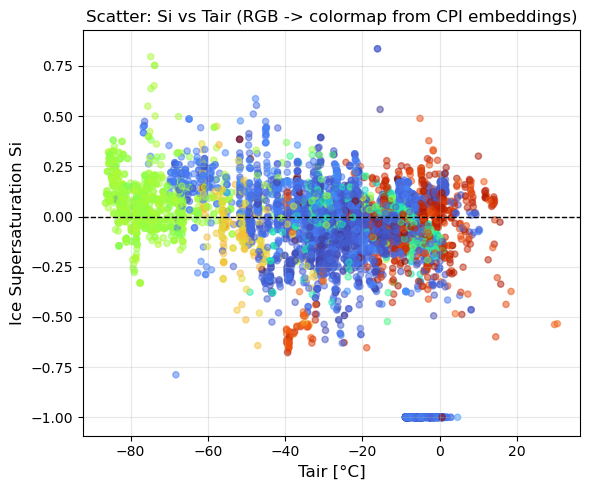

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys
import polars as pl

# -----------------------------
# Step 0: Sample points for plotting (optional)
# -----------------------------
# Convert Polars to Pandas for easy plotting
# n_samples = len(df_merged)
n_samples=10_000
df_plot = df_merged.select(["Tair_C", "Si", "r", "g", "b"]).sample(n=n_samples, seed=42).to_pandas()

# -----------------------------
# Step 1: Convert RGB 0-255 -> 0-1 floats
# -----------------------------
rgb_vals = df_plot[["r", "g", "b"]].values / 255.0

# -----------------------------
# Step 2: Convert RGB -> HSV -> Hue
# -----------------------------
hsv = np.array([colorsys.rgb_to_hsv(r, g, b) for r, g, b in rgb_vals])
hue = hsv[:, 0]  # 0..1

# -----------------------------
# Step 3: Map hue to matplotlib colormap
# -----------------------------
cmap = plt.cm.turbo
colors = cmap(hue)

# -----------------------------
# Step 4: Scatter plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    df_plot["Tair_C"],
    df_plot["Si"],
    c=colors,
    s=20,
    alpha=0.5
)

# Horizontal line at Si=0
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Tair [°C]", fontsize=12)
plt.ylabel("Ice Supersaturation Si", fontsize=12)
plt.title("Scatter: Si vs Tair (RGB -> colormap from CPI embeddings)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

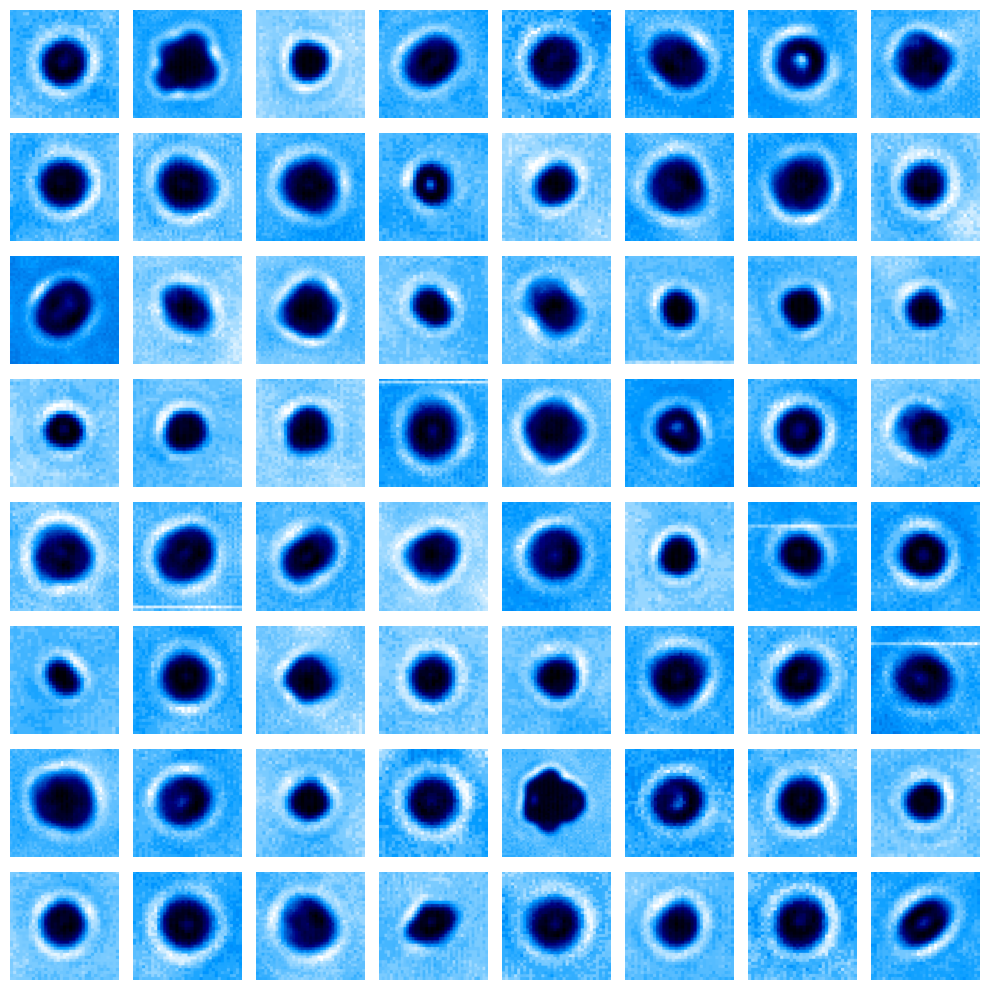

In [67]:
# Show samples of CPI images within user-defined extent.
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------
# Step 0: Define selection criteria
# -----------------------------
cpi_base_dir = '/home/vanessa/hulk/cocpit/cpi_data/campaigns'
tmin, tmax = -90, -80       # Tair extent
smin, smax = 0, 0.25    # Si extent
n_samples = 64            # number of images to plot

# -----------------------------
# Step 1: Filter df_merged based on Tair and Si
# -----------------------------
df_filtered = df_merged.filter(
    (pl.col("Tair_C") >= tmin) & (pl.col("Tair_C") <= tmax) &
    (pl.col("Si") >= smin) & (pl.col("Si") <= smax)
)

# -----------------------------
# Step 2: Sample n_samples images
# -----------------------------
n_available = df_filtered.height
n_take = min(n_samples, n_available)
df_sampled = df_filtered.sample(n=n_take, seed=42)

# -----------------------------
# Step 3: Map campaigns to directory names
# -----------------------------
campaign_dir_map = {
    "CRYSTAL-FACE-NASA": "CRYSTAL_FACE_NASA",
    "CRYSTAL-FACE-UND": "CRYSTAL_FACE_UND",
    # other campaigns map directly
    "ARM": "ARM",
    "MIDCIX": "MIDCIX",
    "MC3E": "MC3E",
    "OLYMPEX": "OLYMPEX"
}

# -----------------------------
# Step 4: Prepare image paths
# -----------------------------
image_paths = []
for row in df_sampled.to_dicts():
    campaign_dir = campaign_dir_map.get(row["campaign"], row["campaign"])
    img_path = os.path.join(
        cpi_base_dir,
        campaign_dir,
        "single_imgs_v1.4.0",
        os.path.basename(row["filename"])
    )
    image_paths.append(img_path)

# -----------------------------
# Step 5: Load images
# -----------------------------
images = []
for path in image_paths:
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        images.append(img)
    else:
        print(f"Warning: {path} does not exist")
        images.append(Image.new("RGB", (64, 64), (0, 0, 0)))  # black placeholder

# -----------------------------
# Step 6: Plot images in a grid
# -----------------------------
grid_size = int(np.ceil(np.sqrt(n_take)))  # make square-ish grid
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < n_take:
        ax.imshow(images[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TO-DO

# Bin relative percent of classes by temp/Si (use supervised labels)

# Ask CPI people spheres. Paul Lawson? Greg M.? 

# expand on similarity metrics as function of thermodynamic variables
